       Patient_ID  Pregnancies  Glucose  BloodPressure BP_Category  \
0               1            6      115             97        High   
1               2            3       84            104      Normal   
2               3           10      199             98        High   
3               4            7      130             60      Normal   
4               5            4      184             81         Low   
...           ...          ...      ...            ...         ...   
11995       11996           10      130             71      Normal   
11996       11997            7       95             79         Low   
11997       11998            4      126             79         Low   
11998       11999            2      201             63         Low   
11999       12000            6      111             89      Normal   

       SkinThickness  Insulin   BMI  Age  HeartDisease  FamilyHistory  \
0                 44      345  32.0   41             1              0   
1            

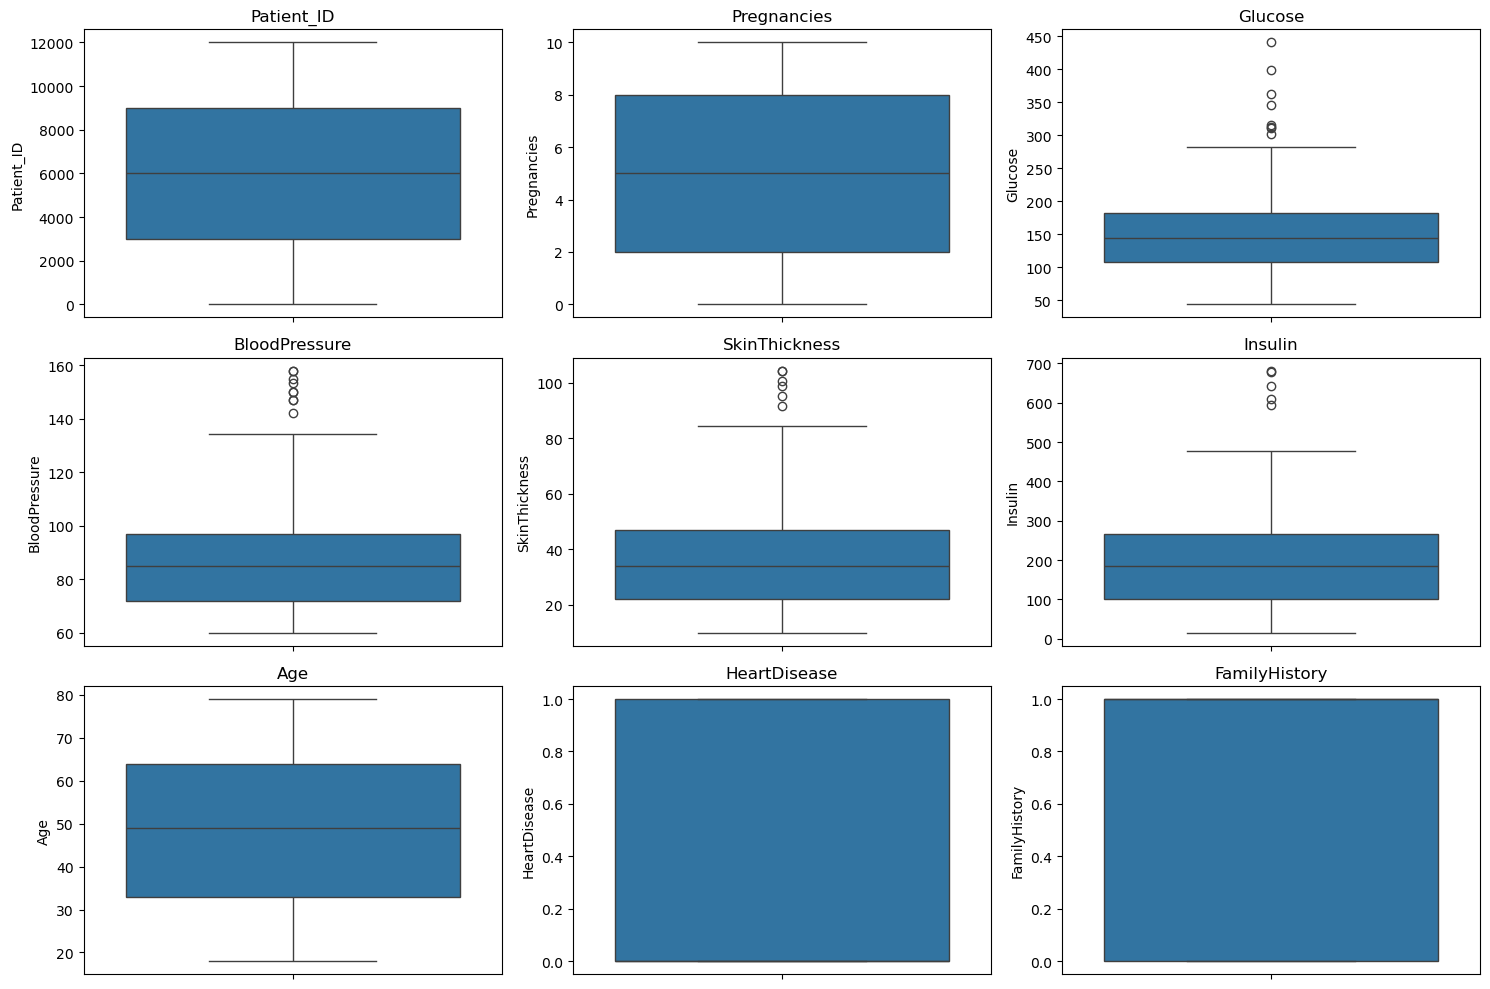

After outlier removal: (11972, 22)


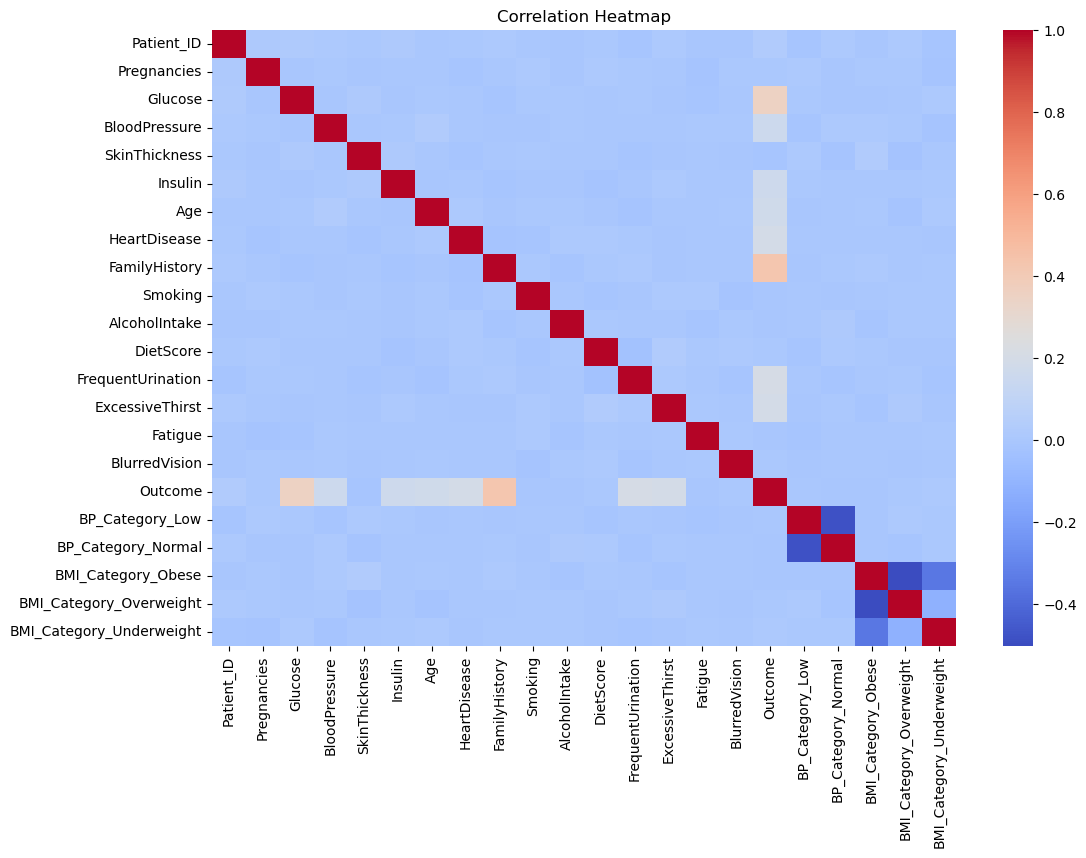

Selected Features: Index(['FamilyHistory', 'Glucose', 'FrequentUrination', 'ExcessiveThirst',
       'HeartDisease', 'Age', 'Insulin', 'BloodPressure', 'Patient_ID'],
      dtype='object')


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
np.random.seed(42)
rows = 12000
data = {
    "Patient_ID": range(1, rows+1),
    "Pregnancies": np.random.randint(0, 11, rows),
    "Glucose": np.random.randint(70, 220, rows),
    "BloodPressure": np.random.randint(60, 110, rows),
    "BP_Category": np.random.choice(["Low", "Normal", "High"], rows),
    "SkinThickness": np.random.randint(10, 60, rows),
    "Insulin": np.random.randint(15, 350, rows),
    "BMI": np.round(np.random.uniform(16.0, 50.0, rows), 1),
    "Age": np.random.randint(18, 80, rows),
    "HeartDisease": np.random.choice([0, 1], rows),
    "FamilyHistory": np.random.choice([0, 1], rows),
    "Smoking": np.random.choice([0, 1], rows),
    "AlcoholIntake": np.random.choice([0, 1, 2], rows),
    "DietScore": np.random.randint(1, 10, rows),
    "FrequentUrination": np.random.choice([0, 1], rows),
    "ExcessiveThirst": np.random.choice([0, 1], rows),
    "Fatigue": np.random.choice([0, 1], rows),
    "BlurredVision": np.random.choice([0, 1], rows)
}


df = pd.DataFrame(data)
print(df)


#preprocessing


df["Glucose"] += np.random.normal(0, 10, rows)

df["BMI"] += np.random.normal(0, 2, rows)

for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    outlier_idx = np.random.choice(df.index, size=25)
    df[col] = df[col].astype(float)
    df.loc[outlier_idx, col] *= np.random.uniform(1.5, 2.0)
for col in df.columns:
    if col != "Patient_ID":
        df.loc[df.sample(frac=0.03).index, col] = np.nan
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"
        
df["BMI_Category"] = df["BMI"].apply(bmi_category)

df.drop("BMI", axis=1, inplace=True)

def calculate_outcome(row):
    score = 0
    if row["Glucose"] > 150: score += 2
    if row["Age"] > 50: score += 1
    if row["BloodPressure"] > 90: score += 1
    if row["Insulin"] > 200: score += 1
    if row["HeartDisease"] == 1: score += 1
    if row["FamilyHistory"] == 1: score += 2
    if row["FrequentUrination"] == 1: score += 1
    if row["ExcessiveThirst"] == 1: score += 1
    return 1 if score >= 4 else 0
df["Outcome"] = df.apply(calculate_outcome, axis=1)
df.fillna(df.median(numeric_only=True))
df.fillna(df.mode().iloc[0])
df = pd.get_dummies(df, columns=["BP_Category", "BMI_Category"], drop_first=True)
num_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols[:9]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
         (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
print("After outlier removal:", df.shape)

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

corr = df.corr()["Outcome"].abs().sort_values(ascending=False)
selected_features = corr[1:10].index 
print("Selected Features:", selected_features)
df.to_csv("db_risk.csv",index=False)







In [2]:
#model training

X = df[selected_features]
y = df["Outcome"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)


from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False
